In [11]:
import os
os.chdir('/home/datahouse1/zengchuanlong/workplace/GeoBFN')
os.getcwd()

'/home/datahouse1/zengchuanlong/workplace/GeoBFN'

In [12]:
import pickle

with open('dataset/competition_round2/competition_round2.pkl', 'rb') as f:
    competition_data = pickle.load(f)

In [13]:
competition_data[0]

{'natoms': 16,
 'coordinates': array([[ 2.90944648e+00, -7.53407887e+00,  3.45550898e+00],
        [ 1.96424648e+00, -8.27297887e+00,  3.45430898e+00],
        [ 6.07846478e-01, -7.96247887e+00,  3.45390898e+00],
        [-1.77353522e-01, -6.82077887e+00,  3.45390898e+00],
        [ 1.37046478e-01, -5.48917887e+00,  3.45400898e+00],
        [ 1.72514648e+00, -4.83187887e+00,  3.45350898e+00],
        [-9.36053522e-01, -4.44177887e+00,  3.45430898e+00],
        [-6.75353522e-01, -3.25537887e+00,  3.45440898e+00],
        [-2.35435352e+00, -4.88027887e+00,  3.45450898e+00],
        [-2.68705352e+00, -6.18057887e+00,  3.45420898e+00],
        [-4.32055352e+00, -6.73457887e+00,  3.45430898e+00],
        [-1.63685352e+00, -7.24007887e+00,  3.45380898e+00],
        [-1.92175352e+00, -8.42187887e+00,  3.45340898e+00],
        [ 2.06844648e+00, -9.38577887e+00,  3.45330898e+00],
        [ 1.84647837e-03, -8.78687887e+00,  3.45330898e+00],
        [-3.09945352e+00, -4.08327887e+00,  3.45480898e

In [14]:
import pandas as pd

# Extract natoms values from competition_data
natoms_data = [mol['natoms'] for mol in competition_data]

# Create a DataFrame
df = pd.DataFrame({'natoms': natoms_data})

# Save to CSV
df.to_csv('natoms_data.csv', index=False)

print(f"Saved {len(natoms_data)} natoms values to natoms_data.csv")
print(f"First few values: {natoms_data[:10]}")

Saved 57252 natoms values to natoms_data.csv
First few values: [16, 15, 27, 27, 17, 14, 14, 14, 27, 27]


In [ ]:
len(competition_data)

57252

In [ ]:
from collections import Counter

# Analyze the competition_data structure and content
print(f"Total number of molecules in competition_data: {len(competition_data)}")
print("\nFirst molecule structure:")
first_mol = competition_data[0]
print(f"Keys: {first_mol.keys()}")
print(f"Number of atoms: {first_mol['natoms']}")
print(f"Elements: {first_mol['elements']}")
print(f"Coordinates shape: {first_mol['coordinates'].shape}")
print(f"Properties value: {first_mol['properties']}")

print("\nSample of molecule sizes:")
sizes = [mol['natoms'] for mol in competition_data[:10]]
print(f"First 10 molecule sizes: {sizes}")

print("\nStatistics of molecule sizes:")
all_sizes = [mol['natoms'] for mol in competition_data]
print(f"Min atoms: {min(all_sizes)}")
print(f"Max atoms: {max(all_sizes)}")
print(f"Average atoms: {sum(all_sizes)/len(all_sizes):.2f}")

print("\nStatistics of properties values:")
all_properties = [mol['properties'] for mol in competition_data]
print(f"Min property: {min(all_properties):.4f}")
print(f"Max property: {max(all_properties):.4f}")
print(f"Average property: {sum(all_properties)/len(all_properties):.4f}")

# Count unique elements across all molecules
all_elements = []
for mol in competition_data:
    all_elements.extend(mol['elements'])
element_counts = Counter(all_elements)
print(f"\nElement distribution (top 10):")
for element, count in element_counts.most_common(10):
    print(f"{element}: {count}")

Total number of molecules in competition_data: 57252

First molecule structure:
Keys: dict_keys(['natoms', 'coordinates', 'elements', 'properties'])
Number of atoms: 16
Elements: [8, 6, 7, 6, 6, 17, 6, 8, 6, 6, 17, 6, 8, 1, 1, 1]
Coordinates shape: (16, 3)
Properties value: 35.551597595214844

Sample of molecule sizes:
First 10 molecule sizes: [16, 15, 27, 27, 17, 14, 14, 14, 27, 27]

Statistics of molecule sizes:
Min atoms: 6
Max atoms: 29
Average atoms: 22.61

Statistics of properties values:
Min property: -4.8820
Max property: 124.0469
Average property: 21.5179

Element distribution (top 10):
1: 598781
6: 456748
7: 116297
8: 90468
16: 15146
9: 9180
17: 6405
15: 810
35: 795


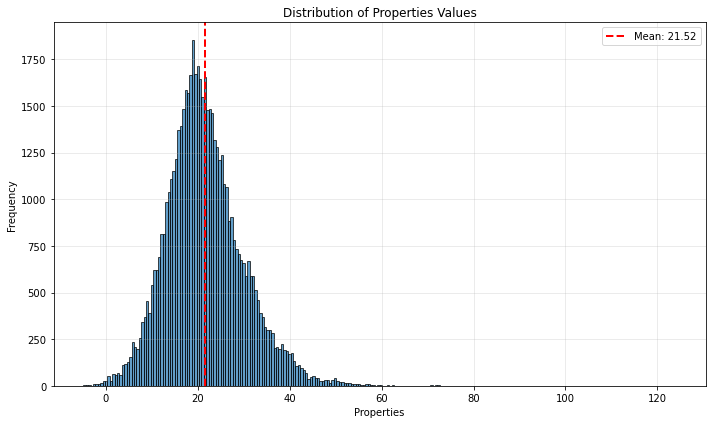

Statistics for properties:
Mean: 21.5179
Standard deviation: 8.3307
Min: -4.8820
Max: 124.0469


In [ ]:
import numpy as np

import matplotlib.pyplot as plt

# Extract properties values from competition_data
properties_values = [mol['properties'] for mol in competition_data]

# Create histogram
plt.figure(figsize=(10, 6))
plt.hist(properties_values, bins='auto', alpha=0.7, edgecolor='black')
plt.title('Distribution of Properties Values')
plt.xlabel('Properties')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# Add statistics text
mean_val = np.mean(properties_values)
std_val = np.std(properties_values)
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Statistics for properties:")
print(f"Mean: {mean_val:.4f}")
print(f"Standard deviation: {std_val:.4f}")
print(f"Min: {min(properties_values):.4f}")
print(f"Max: {max(properties_values):.4f}")